# Problem 1: Temperature Map (8 points)

In this problem, we will work with raster data from the [Finnish Meteorological Institute (FMI)](https://en.ilmatieteenlaitos.fi/), which contains daily average temperatures stored in 10 km by 10 km raster cells. For each year, there is one raster file (we will only work with data from the year 2023), and it contains 365 raster bands—each representing one day of the year, starting from January through to the end of December.

In this exercise, we will work with the raster bands, extract the necessary information, and perform raster calculations.


## (1a) - Read the raster data (1 point)

As the first step read the raster file from data directory `data/tday_2023.tif`. Print the raster metadata. 

In [1]:
import pathlib
NOTEBOOK_PATH = pathlib.Path().resolve()
DATA_DIRECTORY = NOTEBOOK_PATH / "Exercise-6-data"

In [2]:
import rioxarray as rxr

raster_file = DATA_DIRECTORY / 'tday_2023.tif'

temperature_raster = rxr.open_rasterio(raster_file)

In [3]:
# print raster metadata
print(temperature_raster)

<xarray.DataArray (band: 365, y: 116, x: 68)> Size: 12MB
[2879120 values with dtype=float32]
Coordinates:
  * band         (band) int64 3kB 1 2 3 4 5 6 7 ... 359 360 361 362 363 364 365
  * x            (x) float64 544B 6.869e+04 7.869e+04 ... 7.287e+05 7.387e+05
  * y            (y) float64 928B 7.782e+06 7.772e+06 ... 6.642e+06 6.632e+06
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    _FillValue:     -3.4e+38
    scale_factor:   1.0
    add_offset:     0.0


## (1b) - Maximum temperatures per day (2 points)

We aim to extract the maximum temperature across the country for each day of summer. Since each day's data is stored as a raster band, we need to iterate through the bands to the desired value — the maximum temperature for that day (i.e., the highest pixel value) from the relevant bands. We will do this only for the Summer, which spans from June 1st (the 152nd day of the year) to August 31st (the 243rd day of the year). 

For each day, print the day number and the maximum temperature using a f-string formatted to two decimal places, like so: `On summer day number --, the maximum temperature in the country is: --`.

In [4]:
# Summer day span (152nd - 243rd day of the year)
for day_num in range(152, 244):  # Iterate through summer days
    
    # Extract the maximum temperature from the band and format to 2 decimals
    max_temp = float(temperature_raster.sel(band=day_num).values.max())
    
    print(f"On summer day number {day_num}, the maximum temperature in the country is: {max_temp:.2f}")

On summer day number 152, the maximum temperature in the country is: 10.60
On summer day number 153, the maximum temperature in the country is: 9.30
On summer day number 154, the maximum temperature in the country is: 10.90
On summer day number 155, the maximum temperature in the country is: 12.30
On summer day number 156, the maximum temperature in the country is: 14.30
On summer day number 157, the maximum temperature in the country is: 14.00
On summer day number 158, the maximum temperature in the country is: 13.50
On summer day number 159, the maximum temperature in the country is: 12.80
On summer day number 160, the maximum temperature in the country is: 13.00
On summer day number 161, the maximum temperature in the country is: 13.80
On summer day number 162, the maximum temperature in the country is: 17.20
On summer day number 163, the maximum temperature in the country is: 18.40
On summer day number 164, the maximum temperature in the country is: 18.60
On summer day number 165, 

which summer day was the hottest? Just type in the day number in the cell below.

In [5]:
# Find the hottest summer day
max_temp_overall = -float('inf')
hottest_day = None

# Iterate through summer days to find the maximum
for day_num in range(152, 244):
    max_temp = float(temperature_raster.sel(band=day_num).values.max())
    
    if max_temp > max_temp_overall:
        max_temp_overall = max_temp
        hottest_day = day_num

# The hottest summer day, just type in the day number as integer (and not the date)
day_number = hottest_day  # Replace 0 with the correct value
print(day_number)

219


## (1c) - Work with the "hot" raster band (4 points)

Select the band with the hotetst temperature and store it under the variable name `hot_day_raster`. (1 point)

In [6]:
# select your raster band here
hot_day_raster = temperature_raster.sel(band=day_number)
print(hot_day_raster)

<xarray.DataArray (y: 116, x: 68)> Size: 32kB
[7888 values with dtype=float32]
Coordinates:
    band         int64 8B 219
  * x            (x) float64 544B 6.869e+04 7.869e+04 ... 7.287e+05 7.387e+05
  * y            (y) float64 928B 7.782e+06 7.772e+06 ... 6.642e+06 6.632e+06
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    _FillValue:     -3.4e+38
    scale_factor:   1.0
    add_offset:     0.0


Then run the following cell to mask out the null values from your raster.

In [7]:
import xarray as xr
import numpy as np

hot_day_raster = xr.where(hot_day_raster >= 0, hot_day_raster, np.nan)

Then calculate the following for the selected day (use the same variable names as below): (2 points)

- `average_temp`: a float representing the average temperature.
- A printed temperature range f-string formatted as: `"Temperature is ranging between -- and --"`, with both values rounded to two decimal places.

In [10]:
# Calculate average temperature for the hottest day
average_temp = float(np.nanmean(hot_day_raster))

# Calculate minimum and maximum temperature
min_temp = float(np.nanmin(hot_day_raster))
max_temp = float(np.nanmax(hot_day_raster))

# Print temperature range with f-string formatted to two decimal places
print(f"Temperature is ranging between {min_temp:.2f} and {max_temp:.2f}.")

Temperature is ranging between 11.30 and 26.90.


Now plot your hot day raster. (1 point)

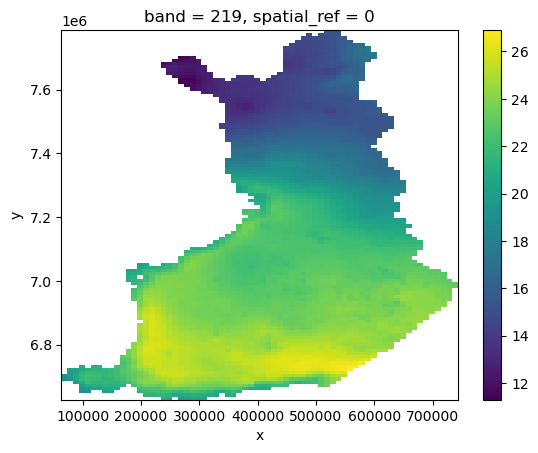

In [11]:
hot_day_raster.plot()

## (1d) - Convert the temperature unit and plot (1 point)

Next, we want to convert the temperatures to degrees Fahrenheit and plot the resulting raster. Name the output raster `hot_day_fahr`.

As we probably remember well from the first period, the conversion formula from Celsius to Fahrenheit is given by:

$$
T_{\text{Fahrenheit}} = T_{\text{Celsius}} \times \frac{9}{5} + 32
$$

Finally, plot the `hot_day_fahr` raster.


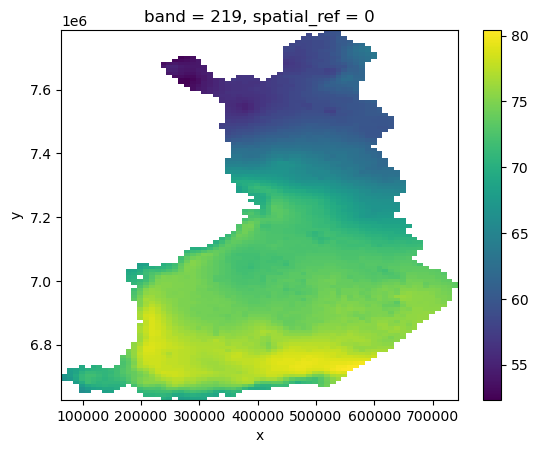

In [12]:
# Convert temperatures from Celsius to Fahrenheit
# Formula: F = C * 9/5 + 32
hot_day_fahr = hot_day_raster * 9/5 + 32

# Plot the converted raster
hot_day_fahr.plot()